# Faktorizacijski model za recommendation

U ovom notebooku je implementiran NMF (Non-negative Matrix Factorization) kao faktorizacijski model za recommendation sistem.

Struktura je namjerno modularna:
- vise pomocnih funkcija
- `main()` orkestruje cijeli postupak

In [ ]:
# Rundown komentara sebi
# 
# Prvo napravim mali dataset ocjena izmedju korisnika i filmova, cisto da imam jasan primjer recommendation problema.
# 
# Onda taj dataset pretvorim u user-item matricu, jer je to prirodan oblik za recommendation: redovi su korisnici, kolone su itemi, a vrijednosti su ocjene.
# 
# Bitno mi je pokazati da je matrica sparse, sto znaci da dosta polja nema vrijednost jer korisnici nisu ocijenili sve filmove. Zato posebno pravim i prikaz sparse obrasca matrice.
# 
# Za sam model prazna mjesta privremeno punim nulama, jer NMF radi nad nenegativnom matricom i tako dobijam matricu pogodnu za faktorizaciju.
# 
# NMF onda razlaze originalnu matricu na dvije manje matrice, `W` i `H`. Intuicija je da one hvataju skrivene latentne osobine korisnika i itema.
# 
# Kad pomnozim `W @ H`, dobijam rekonstruisanu matricu. To vise nije ona originalna sparse matrica, nego gusta matrica procijenjenih ocjena, gdje model popunjava i ono sto je ranije falilo.
# 
# Na kraju iz te rekonstruisane matrice uzimam iteme koje korisnik jos nije ocijenio i predlazem one sa najvecom procijenjenom ocjenom.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.sparse import csr_matrix
from sklearn.decomposition import NMF

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

In [ ]:
def create_ratings_dataset():
    # generisao chatgpt
    ratings = [
        {'user': 'U1', 'item': 'Matrix', 'rating': 5},
        {'user': 'U1', 'item': 'Inception', 'rating': 4},
        {'user': 'U1', 'item': 'Interstellar', 'rating': 5},
        {'user': 'U1', 'item': 'Dune', 'rating': 4},
        {'user': 'U2', 'item': 'Matrix', 'rating': 4},
        {'user': 'U2', 'item': 'Titanic', 'rating': 2},
        {'user': 'U2', 'item': 'Avatar', 'rating': 5},
        {'user': 'U2', 'item': 'Toy_Story', 'rating': 3},
        {'user': 'U2', 'item': 'Shrek', 'rating': 2},
        {'user': 'U3', 'item': 'Inception', 'rating': 5},
        {'user': 'U3', 'item': 'Interstellar', 'rating': 4},
        {'user': 'U3', 'item': 'Dune', 'rating': 5},
        {'user': 'U3', 'item': 'Joker', 'rating': 4},
        {'user': 'U4', 'item': 'Titanic', 'rating': 5},
        {'user': 'U4', 'item': 'Avatar', 'rating': 4},
        {'user': 'U4', 'item': 'Frozen', 'rating': 5},
        {'user': 'U4', 'item': 'Toy_Story', 'rating': 2},
        {'user': 'U5', 'item': 'Toy_Story', 'rating': 5},
        {'user': 'U5', 'item': 'Shrek', 'rating': 4},
        {'user': 'U5', 'item': 'Frozen', 'rating': 4},
        {'user': 'U5', 'item': 'Avatar', 'rating': 3},
        {'user': 'U6', 'item': 'Matrix', 'rating': 2},
        {'user': 'U6', 'item': 'Joker', 'rating': 5},
        {'user': 'U6', 'item': 'Dune', 'rating': 4},
        {'user': 'U6', 'item': 'Shrek', 'rating': 2},
        {'user': 'U6', 'item': 'Interstellar', 'rating': 1},
        {'user': 'U7', 'item': 'Interstellar', 'rating': 5},
        {'user': 'U7', 'item': 'Dune', 'rating': 4},
        {'user': 'U7', 'item': 'Avatar', 'rating': 4},
        {'user': 'U7', 'item': 'Titanic', 'rating': 1},
        {'user': 'U7', 'item': 'Joker', 'rating': 2},
        {'user': 'U8', 'item': 'Toy_Story', 'rating': 4},
        {'user': 'U8', 'item': 'Frozen', 'rating': 5},
        {'user': 'U8', 'item': 'Shrek', 'rating': 5},
        {'user': 'U8', 'item': 'Inception', 'rating': 3},
    ]
    return pd.DataFrame(ratings).sort_values(['user', 'item']).reset_index(drop=True)

def prepare_user_item_matrices(ratings_df):
    user_item_nan = ratings_df.pivot(index='user', columns='item', values='rating').sort_index()

    model_matrix = user_item_nan.fillna(0).astype(float)

    sparsity_mask = user_item_nan.notna().astype(int)

    sparse_matrix = csr_matrix(model_matrix.to_numpy())

    known = int(user_item_nan.notna().sum().sum())

    all_cells = int(user_item_nan.size)

    sparsity = 1 - known / all_cells

    return user_item_nan, model_matrix, sparsity_mask, sparse_matrix, known, all_cells, sparsity

def annotate_heatmap(ax, values, fmt='.2f'):
    finite_values = values[~np.isnan(values)]

    midpoint = (float(finite_values.min()) + float(finite_values.max())) / 2 if finite_values.size else 0

    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            value = values[i, j]

            if np.isnan(value):
                text = ''

                color = '#666666'
            else:
                text = format(float(value), fmt)

                color = 'white' if float(value) >= midpoint else 'black'

            ax.text(j, i, text, ha='center', va='center', color=color, fontsize=10)

def plot_matrix(df, title, cmap='YlGnBu', fmt='.2f', vmin=None, vmax=None, xlabel='Itemi', ylabel='Korisnici'):

    values = df.to_numpy(dtype=float)

    masked_values = np.ma.masked_invalid(values)

    cmap_obj = plt.get_cmap(cmap).copy()

    cmap_obj.set_bad(color='#e6e6e6')

    fig_width = max(8, df.shape[1] * 1.1)

    fig_height = max(4.5, df.shape[0] * 0.8)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    image = ax.imshow(masked_values, aspect='auto', cmap=cmap_obj, vmin=vmin, vmax=vmax)

    ax.set_xticks(np.arange(df.shape[1]))

    ax.set_xticklabels(df.columns, rotation=45, ha='right')

    ax.set_yticks(np.arange(df.shape[0]))

    ax.set_yticklabels(df.index)

    ax.set_title(title)

    ax.set_xlabel(xlabel)

    ax.set_ylabel(ylabel)

    annotate_heatmap(ax, values, fmt=fmt)

    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    
    plt.show()

def factorize_with_nmf(model_matrix, n_components=3, random_state=42):
    nmf_model = NMF(n_components=n_components, init='nndsvda', random_state=random_state, max_iter=1000)

    W = nmf_model.fit_transform(model_matrix.to_numpy())

    H = nmf_model.components_

    W_df = pd.DataFrame(W, index=model_matrix.index, columns=[f'Latent_{i + 1}' for i in range(n_components)])

    H_df = pd.DataFrame(H, index=[f'Latent_{i + 1}' for i in range(n_components)], columns=model_matrix.columns)

    return nmf_model, W_df, H_df

def reconstruct_matrix(W_df, H_df):
    reconstructed = np.clip(W_df.to_numpy() @ H_df.to_numpy(), 0, 5)

    return pd.DataFrame(reconstructed, index=W_df.index, columns=H_df.columns)

def calculate_rmse_on_known_ratings(user_item_nan, model_matrix, reconstructed_df):
    observed_mask = user_item_nan.notna().to_numpy()

    observed_values = model_matrix.to_numpy()[observed_mask]

    predicted_values = reconstructed_df.to_numpy()[observed_mask]

    return float(np.sqrt(np.mean((predicted_values - observed_values) ** 2)))

def generate_recommendations(user_item_nan, reconstructed_df, top_n=3):
    recommendations = []

    for user in user_item_nan.index:
        unseen_mask = user_item_nan.loc[user].isna()

        unseen_scores = reconstructed_df.loc[user, unseen_mask].sort_values(ascending=False).head(top_n)

        for item, score in unseen_scores.items():
            recommendations.append({
                'user': user,
                'recommended_item': item,
                'predicted_rating': round(float(score), 2),
            })

    return pd.DataFrame(recommendations)

def main():
    ratings_df = create_ratings_dataset()

    user_item_nan, model_matrix, sparsity_mask, sparse_matrix, known, all_cells, sparsity = prepare_user_item_matrices(ratings_df)

    _, W_df, H_df = factorize_with_nmf(model_matrix, n_components=3, random_state=42)

    reconstructed_df = reconstruct_matrix(W_df, H_df)

    rmse = calculate_rmse_on_known_ratings(user_item_nan, model_matrix, reconstructed_df)

    recommendations_df = generate_recommendations(user_item_nan, reconstructed_df, top_n=3)

    return {
        'ratings_df': ratings_df,
        'user_item_nan': user_item_nan,
        'model_matrix': model_matrix,
        'sparsity_mask': sparsity_mask,
        'sparse_matrix': sparse_matrix,
        'known': known,
        'all_cells': all_cells,
        'sparsity': sparsity,
        'W_df': W_df,
        'H_df': H_df,
        'reconstructed_df': reconstructed_df,
        'rmse': rmse,
        'recommendations_df': recommendations_df,
    }

## 1. Skup podataka

In [ ]:
results = main()

ratings_df = results['ratings_df']

print(f"Broj ocjena u datasetu: {len(ratings_df)}")

ratings_df

Broj ocjena u datasetu: 35


,user,item,rating
0,U1,Dune,4
1,U1,Inception,4
2,U1,Interstellar,5
3,U1,Matrix,5
4,U2,Avatar,5
5,U2,Matrix,4
6,U2,Shrek,2
7,U2,Titanic,2
8,U2,Toy_Story,3
9,U3,Dune,5


## 2. User-item matrica i sparse prikaz

Originalna user-item matrica (NaN = nema ocjene):


item,Avatar,Dune,Frozen,Inception,Interstellar,Joker,Matrix,Shrek,Titanic,Toy_Story
user,,,,,,,,,,
U1,NaN,4.00,NaN,4.00,5.00,NaN,5.00,NaN,NaN,NaN
U2,5.00,NaN,NaN,NaN,NaN,NaN,4.00,2.00,2.00,3.00
U3,NaN,5.00,NaN,5.00,4.00,4.00,NaN,NaN,NaN,NaN
U4,4.00,NaN,5.00,NaN,NaN,NaN,NaN,NaN,5.00,2.00
U5,3.00,NaN,4.00,NaN,NaN,NaN,NaN,4.00,NaN,5.00
U6,NaN,4.00,NaN,NaN,1.00,5.00,2.00,2.00,NaN,NaN
U7,4.00,4.00,NaN,NaN,5.00,2.00,NaN,NaN,1.00,NaN
U8,NaN,NaN,5.00,3.00,NaN,NaN,NaN,5.00,NaN,4.00


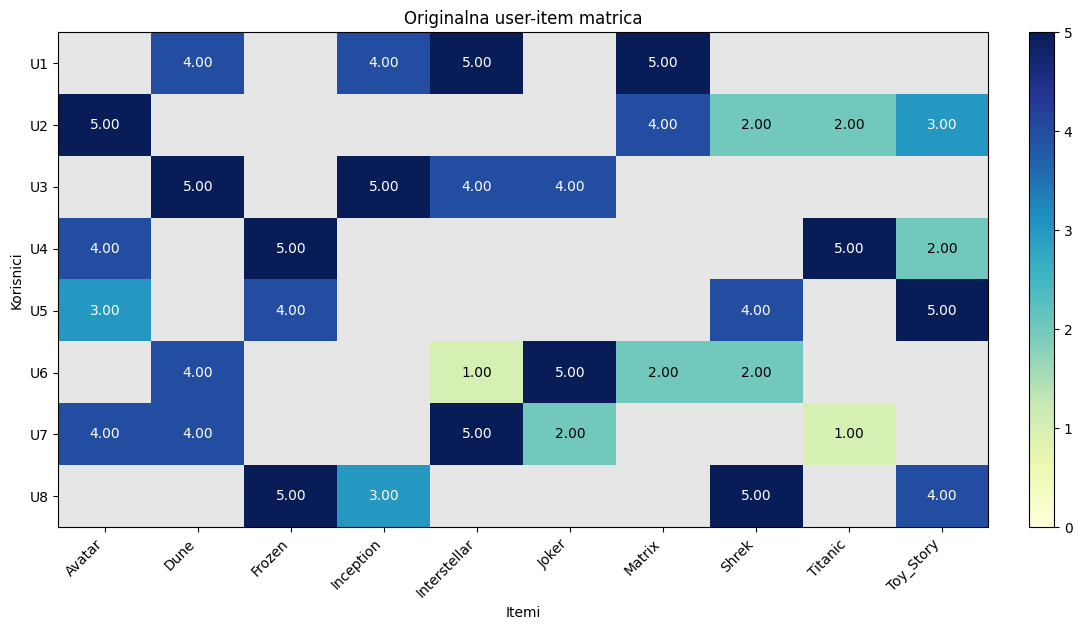

Struktura sparse matrice (1 = postoji ocjena, 0 = prazno):


item,Avatar,Dune,Frozen,Inception,Interstellar,Joker,Matrix,Shrek,Titanic,Toy_Story
user,,,,,,,,,,
U1,0,1,0,1,1,0,1,0,0,0
U2,1,0,0,0,0,0,1,1,1,1
U3,0,1,0,1,1,1,0,0,0,0
U4,1,0,1,0,0,0,0,0,1,1
U5,1,0,1,0,0,0,0,1,0,1
U6,0,1,0,0,1,1,1,1,0,0
U7,1,1,0,0,1,1,0,0,1,0
U8,0,0,1,1,0,0,0,1,0,1


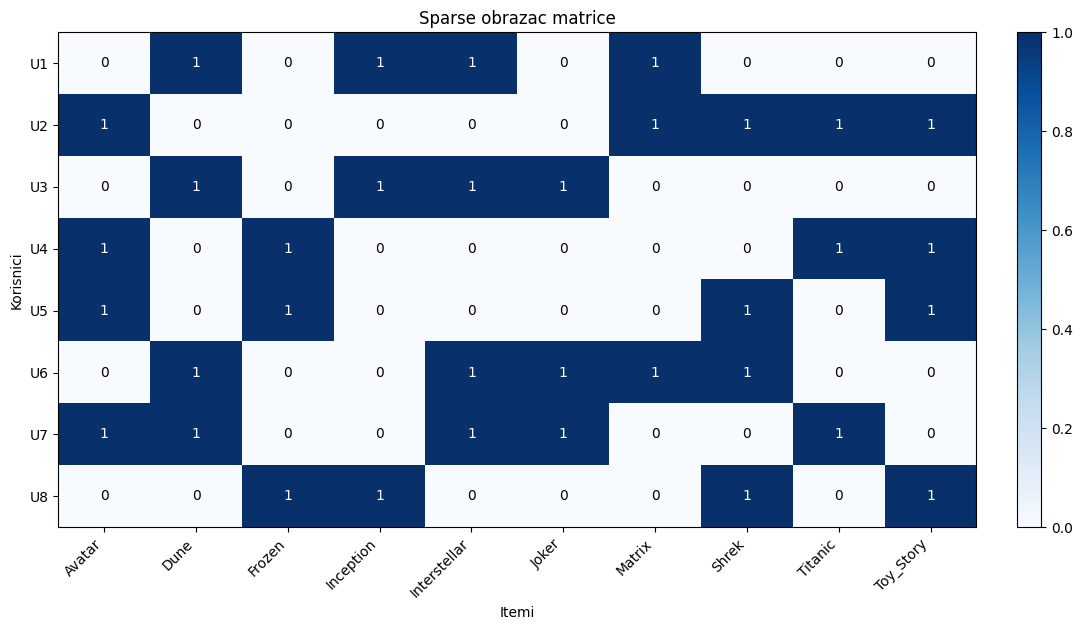

Matrica za model (nepoznate ocjene su 0):


item,Avatar,Dune,Frozen,Inception,Interstellar,Joker,Matrix,Shrek,Titanic,Toy_Story
user,,,,,,,,,,
U1,0.00,4.00,0.00,4.00,5.00,0.00,5.00,0.00,0.00,0.00
U2,5.00,0.00,0.00,0.00,0.00,0.00,4.00,2.00,2.00,3.00
U3,0.00,5.00,0.00,5.00,4.00,4.00,0.00,0.00,0.00,0.00
U4,4.00,0.00,5.00,0.00,0.00,0.00,0.00,0.00,5.00,2.00
U5,3.00,0.00,4.00,0.00,0.00,0.00,0.00,4.00,0.00,5.00
U6,0.00,4.00,0.00,0.00,1.00,5.00,2.00,2.00,0.00,0.00
U7,4.00,4.00,0.00,0.00,5.00,2.00,0.00,0.00,1.00,0.00
U8,0.00,0.00,5.00,3.00,0.00,0.00,0.00,5.00,0.00,4.00


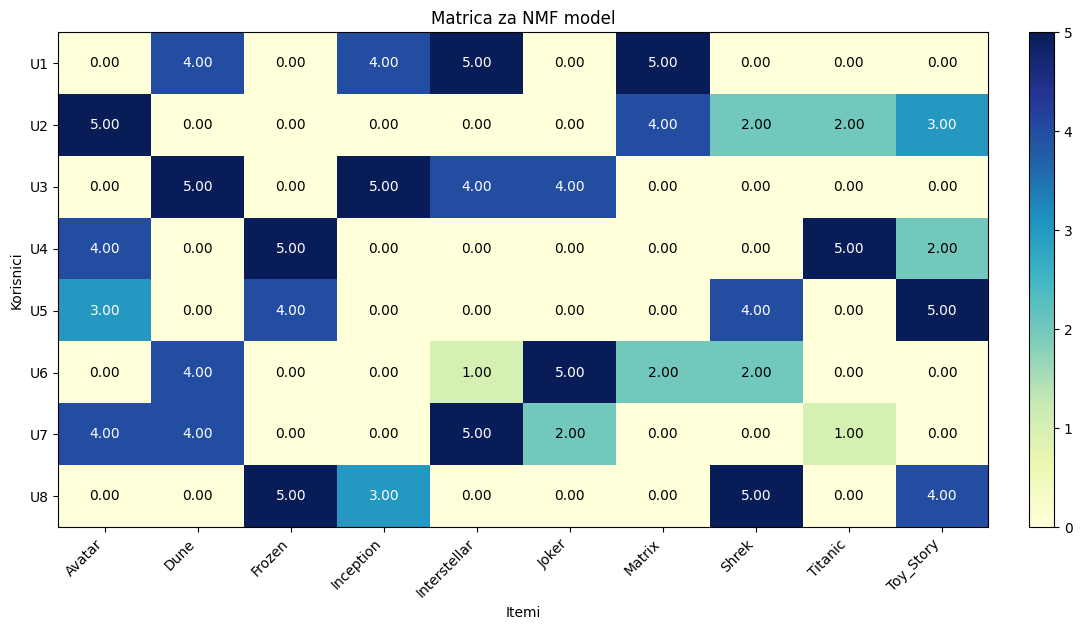

Dimenzije matrice: 8 korisnika x 10 itema
Poznatih ocjena: 35
Ukupno polja u matrici: 80
Sparsity matrice: 56.25%
CSR nnz (broj nenultih elemenata): 35

SciPy CSR prikaz sparse matrice:


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 35 stored elements and shape (8, 10)>

In [ ]:
user_item_nan = results['user_item_nan']

model_matrix = results['model_matrix']

sparsity_mask = results['sparsity_mask']

sparse_matrix = results['sparse_matrix']

known = results['known']

all_cells = results['all_cells']

sparsity = results['sparsity']

print('Originalna user-item matrica (NaN = nema ocjene):')

display(user_item_nan)

plot_matrix(user_item_nan, 'Originalna user-item matrica', vmin=0, vmax=5)

print('Struktura sparse matrice (1 = postoji ocjena, 0 = prazno):')

display(sparsity_mask)

plot_matrix(sparsity_mask, 'Sparse obrazac matrice', cmap='Blues', fmt='.0f', vmin=0, vmax=1)

print('Matrica za model (nepoznate ocjene su 0):')

display(model_matrix)

plot_matrix(model_matrix, 'Matrica za NMF model', vmin=0, vmax=5)

print(f'Dimenzije matrice: {user_item_nan.shape[0]} korisnika x {user_item_nan.shape[1]} itema')

print(f'Poznatih ocjena: {known}')

print(f'Ukupno polja u matrici: {all_cells}')

print(f'Sparsity matrice: {sparsity * 100:.2f}%')

print(f'CSR nnz (broj nenultih elemenata): {sparse_matrix.nnz}')

print('\nSciPy CSR prikaz sparse matrice:')

sparse_matrix

## 3. NMF faktorizacija

In [5]:
W_df = results['W_df']
H_df = results['H_df']

print('W matrica (korisnici x latentne osobine):')
display(W_df.round(3))
print('H matrica (latentne osobine x itemi):')
H_df.round(3)

W matrica (korisnici x latentne osobine):


,Latent_1,Latent_2,Latent_3
user,,,
U1,0.85,0.00,0.00
U2,0.18,0.00,1.12
U3,0.34,0.03,0.00
U4,0.00,0.00,1.46
U5,0.00,0.00,1.68
U6,0.00,0.03,0.03
U7,0.08,0.03,0.24
U8,0.12,0.00,1.51


H matrica (latentne osobine x itemi):


item,Avatar,Dune,Frozen,Inception,Interstellar,Joker,Matrix,Shrek,Titanic,Toy_Story
Latent_1,0.00,4.07,0.00,5.52,5.37,0.00,5.45,0.00,0.00,0.04
Latent_2,39.27,129.66,0.00,29.66,88.92,125.86,0.00,16.53,8.19,0.00
Latent_3,2.00,0.00,2.52,0.25,0.00,0.00,0.28,1.92,1.13,2.42


## 4. Rekonstruisana matrica poslije faktorizacije

Rekonstruisana matrica poslije NMF faktorizacije:


item,Avatar,Dune,Frozen,Inception,Interstellar,Joker,Matrix,Shrek,Titanic,Toy_Story
user,,,,,,,,,,
U1,0.08,3.72,0.00,4.78,4.76,0.24,4.66,0.03,0.02,0.04
U2,2.25,0.71,2.83,1.25,0.94,0.00,1.27,2.16,1.27,2.73
U3,1.15,5.00,0.00,2.71,4.39,3.67,1.82,0.48,0.24,0.01
U4,2.93,0.04,3.67,0.37,0.03,0.04,0.41,2.81,1.65,3.53
U5,3.36,0.00,4.24,0.42,0.00,0.00,0.48,3.23,1.91,4.07
U6,1.21,3.79,0.08,0.87,2.60,3.68,0.01,0.55,0.28,0.08
U7,1.63,4.08,0.62,1.37,3.01,3.65,0.51,0.95,0.51,0.60
U8,3.03,0.47,3.81,1.01,0.62,0.00,1.06,2.91,1.72,3.67


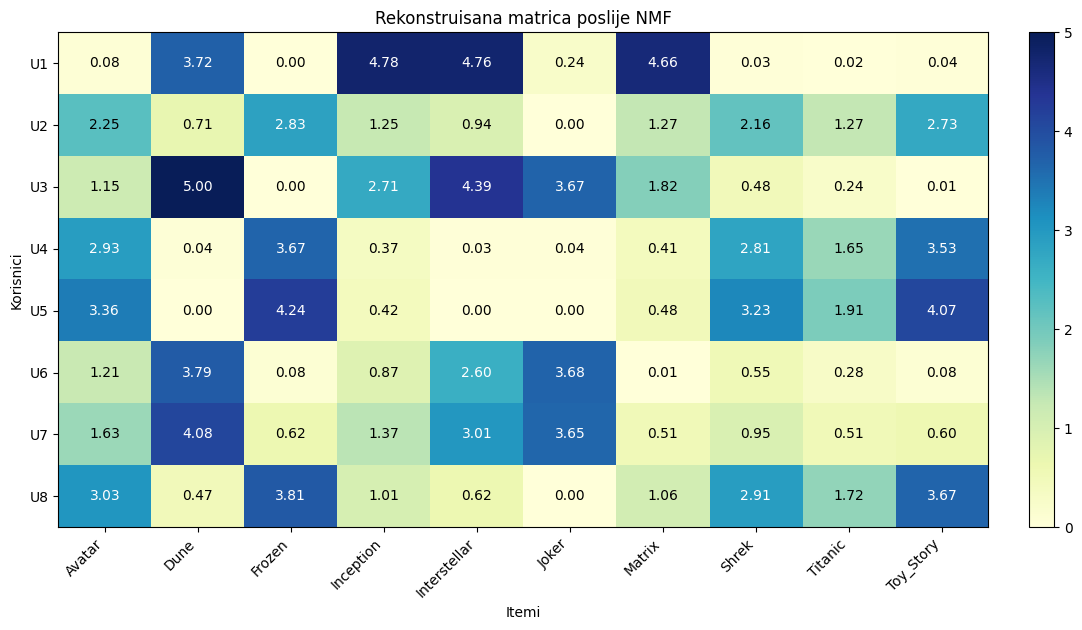

RMSE na poznatim ocjenama: 1.443
Broj skoro-nultih elemenata u rekonstruisanoj matrici (< 0.01): 8
Zakljucak: poslije faktorizacije dobijamo gustu matricu procijenjenih ocjena.


item,Avatar,Dune,Frozen,Inception,Interstellar,Joker,Matrix,Shrek,Titanic,Toy_Story
user,,,,,,,,,,
U1,0.08,3.72,0.00,4.78,4.76,0.24,4.66,0.03,0.02,0.04
U2,2.25,0.71,2.83,1.25,0.94,0.00,1.27,2.16,1.27,2.73
U3,1.15,5.00,0.00,2.71,4.39,3.67,1.82,0.48,0.24,0.01
U4,2.93,0.04,3.67,0.37,0.03,0.04,0.41,2.81,1.65,3.53
U5,3.36,0.00,4.24,0.42,0.00,0.00,0.48,3.23,1.91,4.07
U6,1.21,3.79,0.08,0.87,2.60,3.68,0.01,0.55,0.28,0.08
U7,1.63,4.08,0.62,1.37,3.01,3.65,0.51,0.95,0.51,0.60
U8,3.03,0.47,3.81,1.01,0.62,0.00,1.06,2.91,1.72,3.67


In [6]:
reconstructed_df = results['reconstructed_df']
rmse = results['rmse']

print('Rekonstruisana matrica poslije NMF faktorizacije:')
display(reconstructed_df.round(2))
plot_matrix(reconstructed_df, 'Rekonstruisana matrica poslije NMF', vmin=0, vmax=5)

print(f'RMSE na poznatim ocjenama: {rmse:.3f}')
print(f'Broj skoro-nultih elemenata u rekonstruisanoj matrici (< 0.01): {int((reconstructed_df < 0.01).sum().sum())}')
print('Zakljucak: poslije faktorizacije dobijamo gustu matricu procijenjenih ocjena.')
reconstructed_df.round(2)

## 5. Primjer preporuka

In [7]:
recommendations_df = results['recommendations_df']
recommendations_df

,user,recommended_item,predicted_rating
0,U1,Joker,0.24
1,U1,Avatar,0.08
2,U1,Toy_Story,0.04
3,U2,Frozen,2.83
4,U2,Inception,1.25
5,U2,Interstellar,0.94
6,U3,Matrix,1.82
7,U3,Avatar,1.15
8,U3,Shrek,0.48
9,U4,Shrek,2.81


## Kratak zakljucak

- Originalni skup podataka je nepotpun i daje sparse user-item matricu.
- NMF matricu razlaze na latentne faktore `W` i `H`.
- Mnozenjem `W @ H` dobijamo novu gustu matricu procijenjenih ocjena.
- `main()` samo orkestruje korake, dok su ostali dijelovi izdvojeni u zasebne funkcije.